In [1]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Postdoc\Compressed_sensing\compressed_sensing_bioacoustics\src


In [11]:
from compress import CS
import time
import os
from pathlib import Path
import datetime
from codecarbon import EmissionsTracker
import psutil
import threading
import gc
import pickle

In [3]:
def monitor_resources(stop_event, cpu_usage, mem_usage, sampling_interval=0.1):
    """
    Monitor CPU and memory usage of the current process at regular intervals.
    - cpu_usage: list to store CPU usage (%) over time
    - mem_usage: list to store memory usage (MB) over time
    """
    process = psutil.Process(os.getpid())
    
    while not stop_event.is_set():
        # CPU percent since last call (per process)
        cpu = process.cpu_percent(interval=None)
        # Memory usage (RSS in MB)
        mem = process.memory_info().rss / (1024 ** 2)
        
        cpu_usage.append(cpu)
        mem_usage.append(mem)
        
        time.sleep(sampling_interval)

In [4]:
gc.collect()


13

In [5]:
#parameters species
folder_audio="C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Gibbon/Audio"
folder_saved="C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Gibbon/Compressed_Audio"
folder_tracking="C:/Users/loren/Documents/Postdoc/Compressed_sensing/Data/Gibbon/tracking"
compression_rate=0.4
sample_rate=9600       # raw bat recording sample rate (256 kHz)

#parameter cs
# 1024 samples @ 256 kHz = 4 ms per frame — matches one bat call timescale
# and is equivalent to n_fft=512 at the 128 kHz downsampled rate used by the mel-spectrogram
frame_size=1024
overlap=0.25
compression_mode="reconstruction" #compression or reconstruction

In [6]:
os.cpu_count()

20

In [7]:
n_jobs=os.cpu_count() - 1
n_jobs=10

In [18]:
cs=CS(folder_audio, folder_saved, sample_rate, frame_size, overlap, compression_rate=compression_rate, n_jobs=n_jobs)

folder where to save :  C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_reconstructed_0.4


In [19]:
idx=cs.compress_matrix_1D()


In [ ]:
file_name=f"{cs.folder_compressed_saved}/idx_matrix.pkl"


NameError: name 'idx' is not defined

In [9]:
file_name_no_extension="HGSM3B_0+1_20160329_054000"
file=file_name_no_extension+".WAV"

In [20]:
import librosa
import pickle
audio, sample_rate = librosa.load(Path(cs.folder_audio, file),sr=None)

In [23]:
file_name=f"{cs.folder_compressed_saved}/idx_matrix.pkl"
with open(file_name, "wb") as f:
        pickle.dump(idx, f) 

## Legacy

In [9]:
cs.compress_one_file_legacy(audio, sample_rate, idx, file_name_no_extension)

NameError: name 'audio' is not defined

In [24]:
cs.reconstruction_legacy(solver="lasso", alpha=1e-7, saved_in_wav=True)

100%|██████████| 8398/8398 [03:08<00:00, 44.49it/s]


['2026-07-17 12:01:19.1']

## New function

In [21]:
cs.compress_one_file(audio, sample_rate, idx, file_name_no_extension)

Compressing audio segments: 100%|██████████| 33/33 [00:00<00:00, 3183.86batch/s]


array([[-0.00854492,  0.03762817,  0.02580261, ...,  0.02030945,
        -0.00260925, -0.0243988 ],
       [ 0.02288818, -0.00076294, -0.00553894, ...,  0.03546143,
         0.05410767,  0.04701233],
       [ 0.04521179, -0.03463745, -0.02954102, ...,  0.03840637,
         0.0358429 , -0.02474976],
       ...,
       [ 0.02671814,  0.00665283,  0.02505493, ...,  0.01330566,
         0.0149231 ,  0.00894165],
       [ 0.02607727,  0.00209045,  0.00926208, ...,  0.01896667,
         0.03205872,  0.02778625],
       [ 0.01545715,  0.01879883,  0.01820374, ...,  0.03593445,
         0.02297974,  0.02110291]], dtype=float32)

In [10]:
cs.reconstruction(solver="lasso", alpha=1e-7, saved_in_wav=True)

100%|██████████| 8398/8398 [02:58<00:00, 47.01it/s] 


['2026-07-17 13:11:18.2']

In [24]:
cs.reconstruction(solver="fista", alpha=1e-7, saved_in_wav=True)

Reconstructing (FISTA): 100%|██████████| 33/33 [09:54<00:00, 18.01s/batch]


['2026-07-20 16:09:40.5']

In [26]:
file_cs=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_reconstructed_0.4\HGSM3AB_0+1_20160303_060100_reconstructed.wav"
file=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Audio\HGSM3AB_0+1_20160303_060100.wav"

In [32]:
audio_cs, sr_cs=librosa.load(file_cs, sr=None)

In [33]:
len(audio_cs)/sr_cs

4087.306666666667

In [31]:
sr

9600

In [34]:
audio, sr=librosa.load(file, sr=None)

In [35]:
len(audio)/sr

4087.36

In [40]:
from preprocess import Preprocessing
from settings import Config
from config_species import get_settings


selected_species = "gibbon" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon"

config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.4"
preprocess = Preprocessing(
            **config.preprocessing.dict(),
            species_folder=config.data.species_folder,
            positive_class=config.data.positive_class,
            negative_class=config.data.negative_class,
        )

Loaded settings for: gibbon
{'sample_rate': 9600, 'lowpass_cutoff': 2000, 'downsample_rate': 4800, 'nyquist_rate': 2400, 'segment_duration': 4, 'nb_negative_class': 10, 'annotation_extension': '.svl', 'audio_extension': '.wav', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1000, 'f_max': 2000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Gibbon'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'gibbon', 'negative_class': 'no-gibbon'}


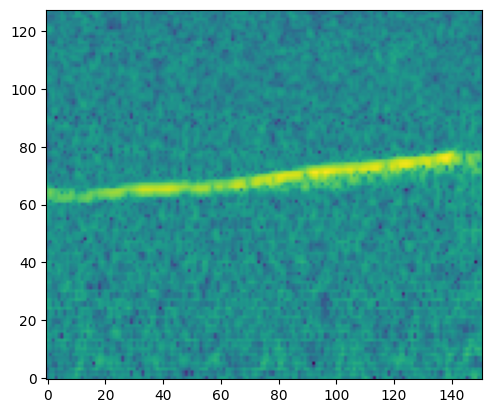

In [55]:
a=(60*60+24)*9600
b=a+4*9600
spec=preprocess.convert_single_to_image(audio[a:b], sr)
plt.imshow(spec,  origin='lower')

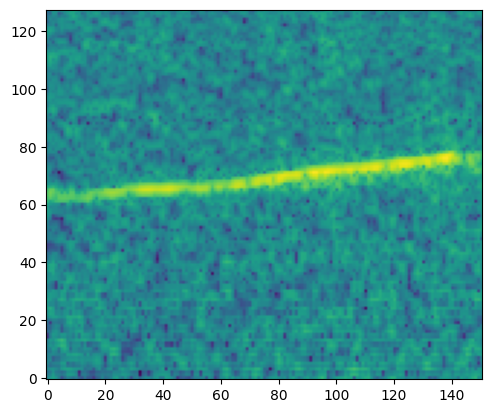

In [56]:
spec_cs=preprocess.convert_single_to_image(audio_cs[a:b], sr_cs)
plt.imshow(spec_cs,  origin='lower')

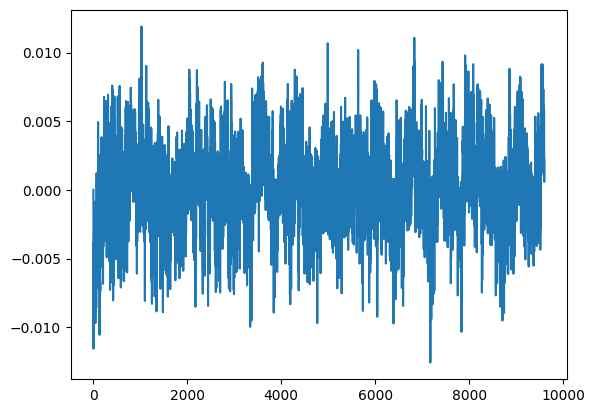

In [38]:
import matplotlib.pyplot as plt
plt.plot(audio_cs[0:9600])

# convert npy folder into wav folder

In [2]:
from pathlib import Path
import numpy as np
from scipy.io.wavfile import write

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
input_folder = Path(r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_reconstructed_0.4")
output_folder = Path(r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Gibbon\Compressed_Audio\cs_reconstructed_0.4_wav")
sample_rate = 9600      # Change to 32000 or 48000 if needed

output_folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Convert all .npy files
# ------------------------------------------------------------------
for npy_file in input_folder.glob("*.npy"):

    print(f"Converting {npy_file.name}")

    # Load signal
    audio = np.load(npy_file)

    # Ensure float
    audio = audio.astype(np.float32)

    # Clip to [-1,1]
    audio = np.clip(audio, -1.0, 1.0)

    # Convert to int16
    audio_int16 = (audio * 32767).astype(np.int16)

    # Output filename
    wav_file = output_folder / f"{npy_file.stem}.wav"

    # Save
    write(wav_file, sample_rate, audio_int16)

print("Done!")

Converting HGSM3AB_0+1_20160303_060100_reconstructed.npy
Converting HGSM3AB_0+1_20160304_060000_reconstructed.npy
Converting HGSM3AB_0+1_20160305_055900_reconstructed.npy
Converting HGSM3AB_0+1_20160310_055600_reconstructed.npy
Converting HGSM3AB_0+1_20160316_055100_reconstructed.npy
Converting HGSM3AB_0+1_20160317_055000_2_reconstructed.npy
Converting HGSM3AB_0+1_20160317_055000_reconstructed.npy
Converting HGSM3AB_0+1_20160330_053900_reconstructed.npy
Converting HGSM3AB_0+1_20160331_053800_reconstructed.npy
Converting HGSM3AC_0+1_20150616_050750_reconstructed.npy
Converting HGSM3AC_0+1_20150618_050600_reconstructed.npy
Converting HGSM3AC_0+1_20150619_050600_1_reconstructed.npy
Converting HGSM3AC_0+1_20150619_050600_reconstructed.npy
Converting HGSM3AC_0+1_20150621_050600_1_reconstructed.npy
Converting HGSM3AC_0+1_20150621_050600_2_reconstructed.npy
Converting HGSM3AC_0+1_20150621_050600_reconstructed.npy
Converting HGSM3AC_0+1_20150622_050600_1_reconstructed.npy
Converting HGSM3AC_0+